# Notebook 04 - Marketing, web và khuyến mãi

**Mục tiêu:** phân tích chất lượng traffic, nguồn truy cập, mức độ dùng khuyến mãi, hiệu quả campaign và tín hiệu uplift doanh thu. Notebook này giúp đề xuất kênh hoặc promo nên scale/tối ưu.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import FIGURES_DIR, WEEKDAY_ORDER, AGE_ORDER, SIZE_ORDER
from EDA.utils.io import load_tables, build_order_metrics, build_order_item_metrics
from EDA.utils.plotting import setup_vietnamese_style, save_figure, format_money_axis, format_percent_axis, money_formatter
from EDA.utils.validation import quality_report, foreign_key_report

setup_vietnamese_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Tải dữ liệu và lưu ý về grain

In [2]:
tables = load_tables(["web_traffic", "promotions", "orders", "order_items", "sales"])
traffic, promos, orders, items, sales = tables["web_traffic"], tables["promotions"], tables["orders"], tables["order_items"], tables["sales"]
display(quality_report(tables))
item = build_order_item_metrics(items).merge(orders[["order_id", "order_date", "order_source", "device_type", "order_status"]], on="order_id", how="left")
display(Markdown(f"**Insight ngắn:** `web_traffic.csv` có {len(traffic):,} dòng và {traffic.date.nunique():,} ngày. Mỗi ngày có một `traffic_source`, vì vậy traffic được dùng như tín hiệu nguồn chính theo ngày, không suy diễn conversion cấp người dùng."))

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
3,order_items,714669,7,1152816,0,80.1100
2,orders,646945,8,0,0,182.5200
1,promotions,50,10,40,0,0.0200
4,sales,3833,3,0,0,0.0900
0,web_traffic,3652,7,0,0,0.4100


**Insight ngắn:** `web_traffic.csv` có 3,652 dòng và 3,652 ngày. Mỗi ngày có một `traffic_source`, vì vậy traffic được dùng như tín hiệu nguồn chính theo ngày, không suy diễn conversion cấp người dùng.

## 2. Chất lượng traffic theo nguồn

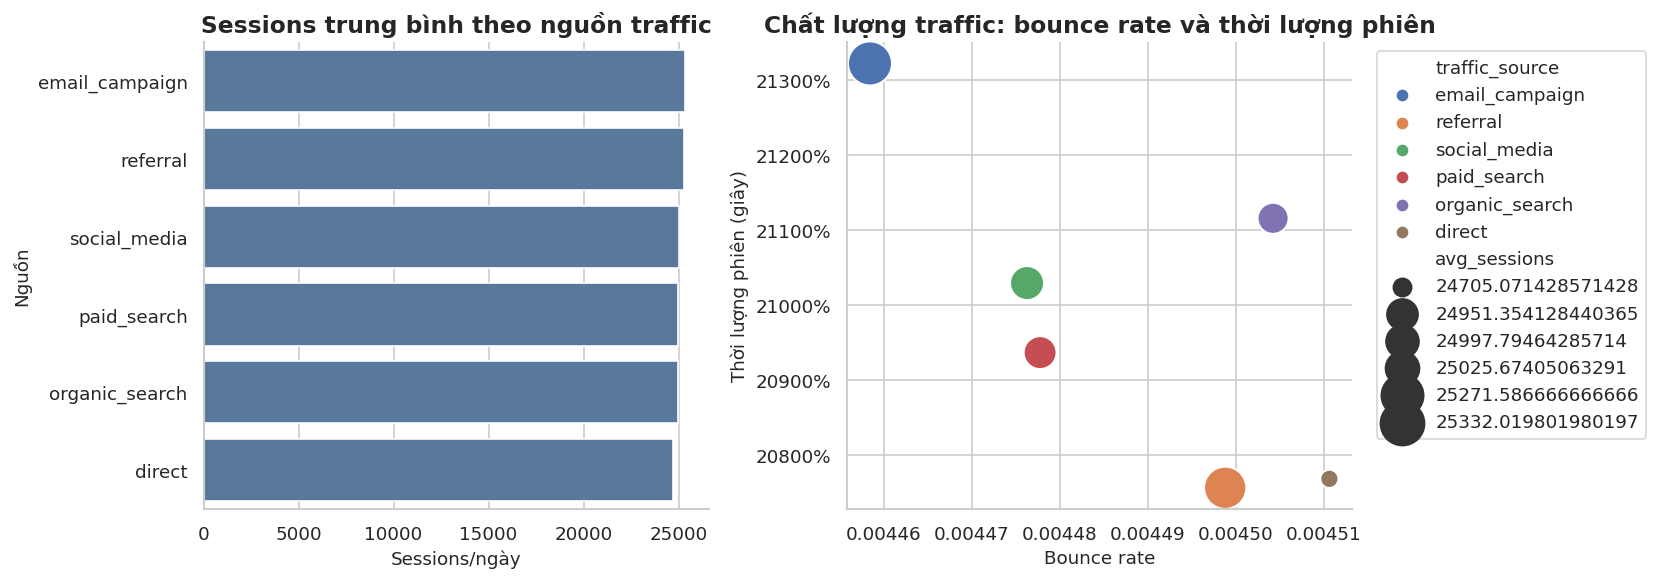

,traffic_source,days,avg_sessions,avg_visitors,avg_page_views,avg_bounce_rate,avg_duration
1,email_campaign,505,"25,332","19,209","109,857",0.45%,213.2
4,referral,375,"25,272","19,253","111,082",0.45%,207.6
5,social_media,632,"25,026","19,063","107,709",0.45%,210.3
3,paid_search,784,"24,998","19,034","108,520",0.45%,209.4
2,organic_search,1090,"24,951","18,922","107,896",0.45%,211.2
0,direct,266,"24,705","18,747","108,163",0.45%,207.7


**Insight ngắn:** nguồn `email_campaign` có tín hiệu chất lượng tốt nhất khi ưu tiên bounce rate thấp và thời lượng phiên cao.

In [3]:
source = traffic.groupby("traffic_source", as_index=False).agg(days=("date", "nunique"), avg_sessions=("sessions", "mean"), avg_visitors=("unique_visitors", "mean"), avg_page_views=("page_views", "mean"), avg_bounce_rate=("bounce_rate", "mean"), avg_duration=("avg_session_duration_sec", "mean")).sort_values("avg_sessions", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=source, y="traffic_source", x="avg_sessions", color="#4c78a8", ax=axes[0])
axes[0].set_title("Sessions trung bình theo nguồn traffic"); axes[0].set_xlabel("Sessions/ngày"); axes[0].set_ylabel("Nguồn")
sns.scatterplot(data=source, x="avg_bounce_rate", y="avg_duration", size="avg_sessions", hue="traffic_source", sizes=(120, 700), ax=axes[1])
axes[1].set_title("Chất lượng traffic: bounce rate và thời lượng phiên"); axes[1].set_xlabel("Bounce rate"); axes[1].set_ylabel("Thời lượng phiên (giây)"); format_percent_axis(axes[1]); axes[1].legend(bbox_to_anchor=(1.03, 1), loc="upper left")
save_figure("04_marketing_web_traffic_quality", fig); plt.show()
best_quality = source.sort_values(["avg_bounce_rate", "avg_duration"], ascending=[True, False]).iloc[0].traffic_source
display(source.style.format({"avg_sessions": "{:,.0f}", "avg_visitors": "{:,.0f}", "avg_page_views": "{:,.0f}", "avg_bounce_rate": "{:.2%}", "avg_duration": "{:.1f}"}))
display(Markdown(f"**Insight ngắn:** nguồn `{best_quality}` có tín hiệu chất lượng tốt nhất khi ưu tiên bounce rate thấp và thời lượng phiên cao."))

## 3. Traffic và doanh thu theo thời gian

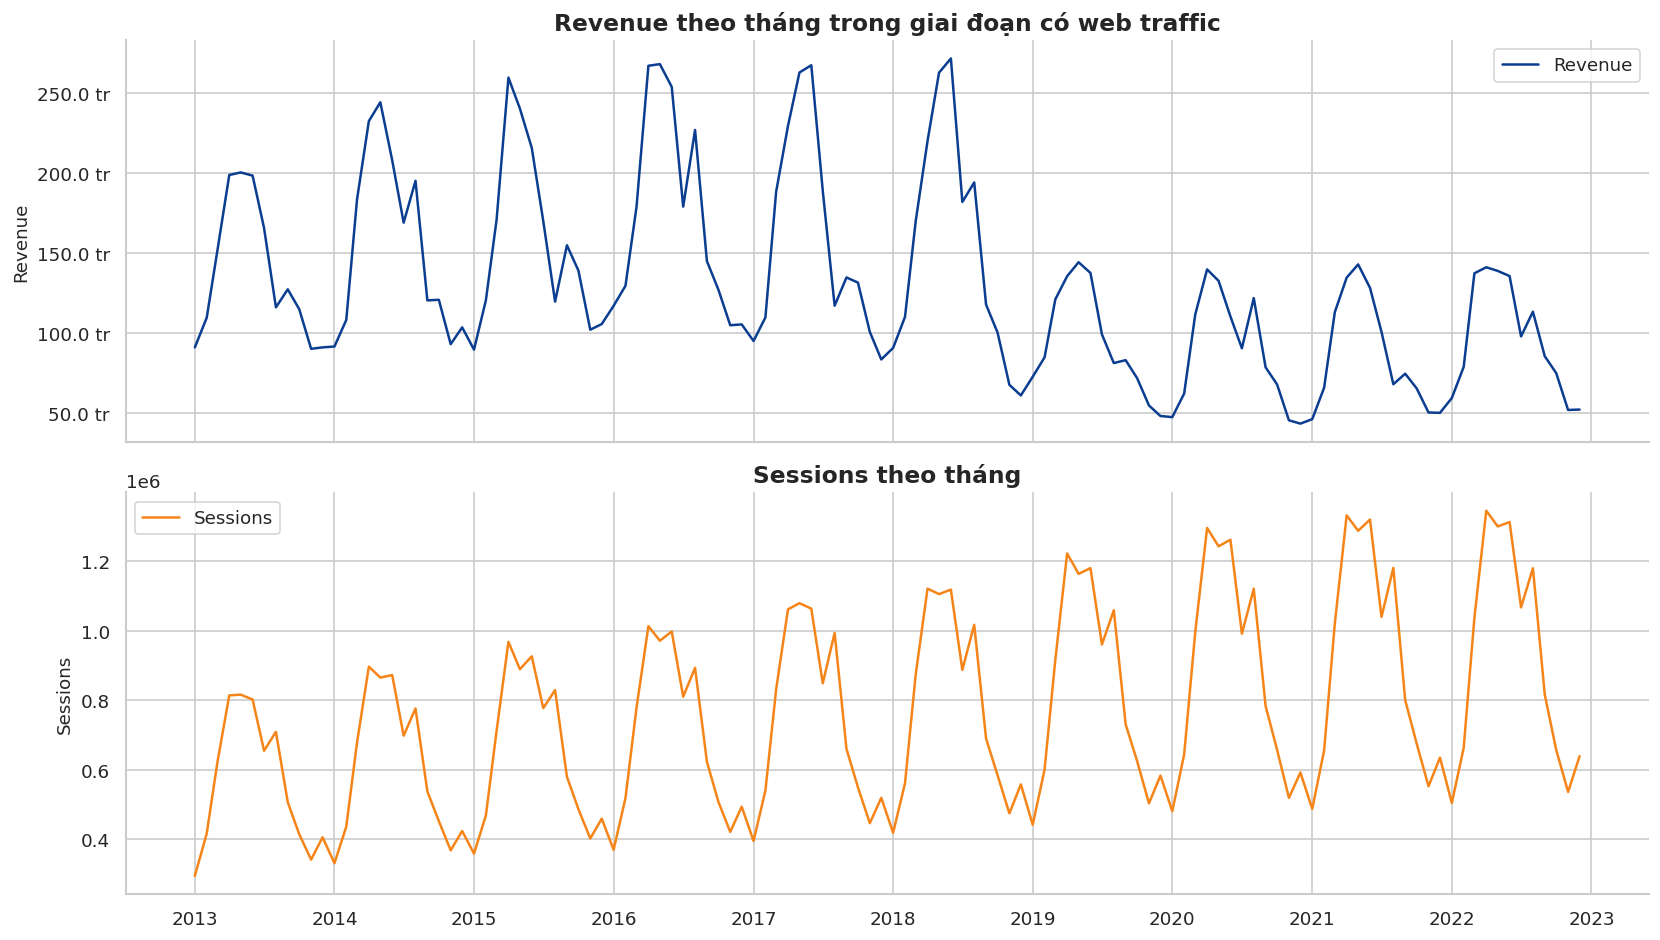

,corr_with_revenue
sessions,0.321
unique_visitors,0.319
page_views,0.302
bounce_rate,-0.021
avg_session_duration_sec,-0.026


**Insight ngắn:** tín hiệu web liên hệ mạnh nhất với Revenue là `sessions`; cần kiểm soát mùa vụ trước khi dùng làm bằng chứng nhân quả.

In [4]:
st = sales.merge(traffic, left_on="Date", right_on="date", how="inner")
st["month"] = st.Date.dt.to_period("M").dt.to_timestamp()
monthly = st.groupby("month", as_index=False).agg(Revenue=("Revenue", "sum"), sessions=("sessions", "sum"), page_views=("page_views", "sum"), avg_bounce_rate=("bounce_rate", "mean"))
monthly["revenue_per_session"] = monthly.Revenue / monthly.sessions
corr = st[["Revenue", "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]].corr(numeric_only=True)["Revenue"].drop("Revenue")
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(monthly.month, monthly.Revenue, color="#0b3d91", label="Revenue"); axes[0].set_title("Revenue theo tháng trong giai đoạn có web traffic"); axes[0].set_ylabel("Revenue"); format_money_axis(axes[0]); axes[0].legend()
axes[1].plot(monthly.month, monthly.sessions, color="#f58518", label="Sessions"); axes[1].set_title("Sessions theo tháng"); axes[1].set_ylabel("Sessions"); axes[1].legend()
save_figure("04_marketing_web_traffic_revenue_time", fig); plt.show()
display(corr.to_frame("corr_with_revenue").style.format("{:.3f}"))
display(Markdown(f"**Insight ngắn:** tín hiệu web liên hệ mạnh nhất với Revenue là `{corr.abs().sort_values(ascending=False).index[0]}`; cần kiểm soát mùa vụ trước khi dùng làm bằng chứng nhân quả."))

## 4. Khuyến mãi: mức độ dùng, độ sâu giảm giá và uplift

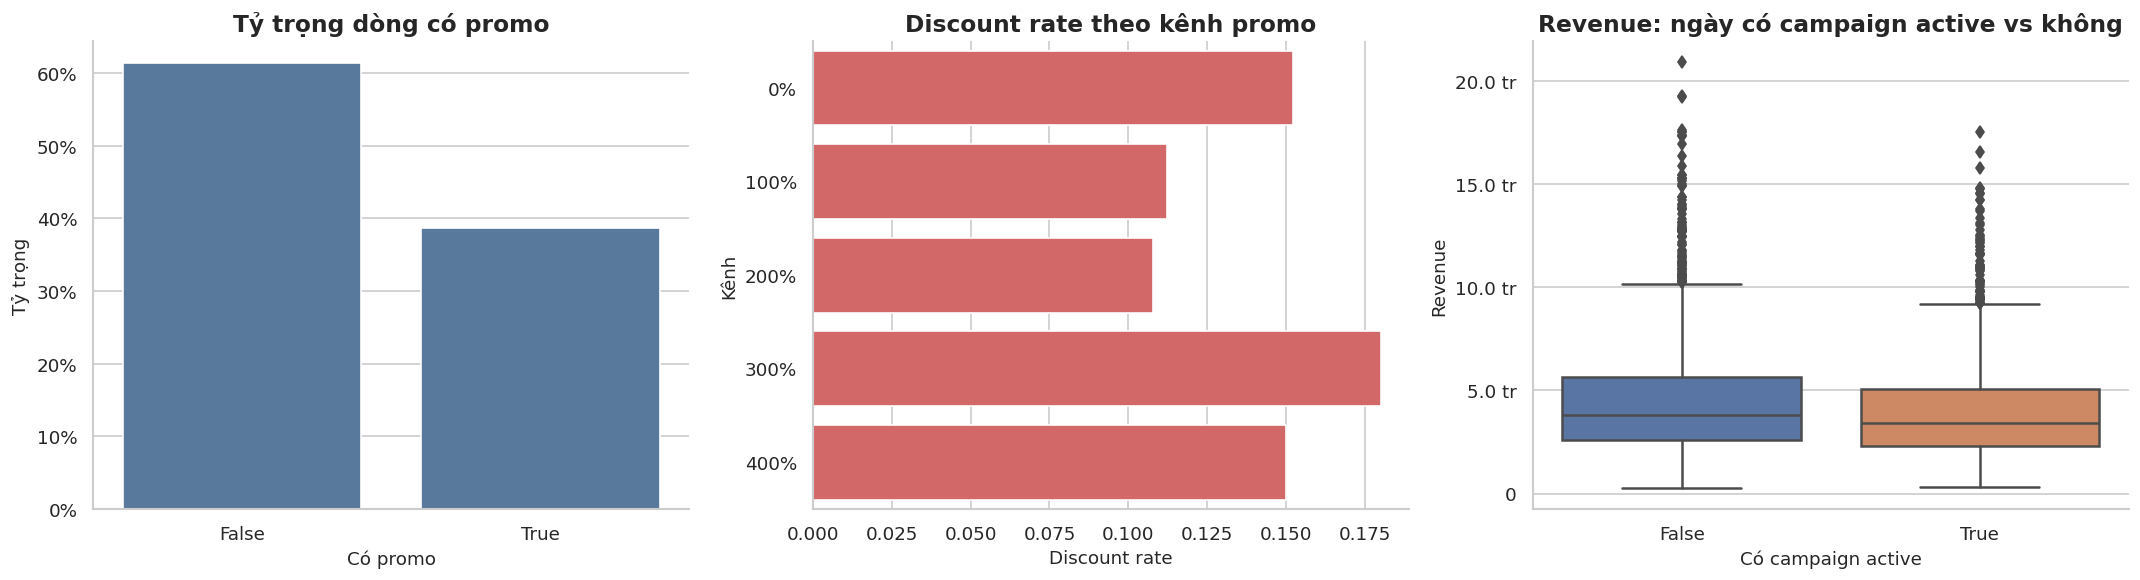

,active_promo_day,days,avg_revenue,median_revenue,avg_margin
0,False,2126,"4,524,083","3,819,856",19.84%
1,True,1707,"3,990,789","3,428,607",3.45%


**Insight ngắn:** 38.66% dòng sản phẩm có promo chính; ngày có campaign active có uplift doanh thu mô tả khoảng -11.79%. Đây chưa phải tác động nhân quả tuyệt đối vì còn mùa vụ.

In [5]:
usage = item.groupby("has_promo", as_index=False).agg(lines=("product_id", "count"), units=("quantity", "sum"), gross_sales=("gross_sales", "sum"), net_sales=("net_sales", "sum"), discount_amount=("discount_amount", "sum"))
usage["line_share"] = usage.lines / usage.lines.sum()
usage["discount_rate"] = usage.discount_amount / usage.gross_sales
promo_lines = item[item.promo_id.notna()].merge(promos, on="promo_id", how="left")
promo_channel = promo_lines.groupby("promo_channel", as_index=False).agg(lines=("product_id", "count"), net_sales=("net_sales", "sum"), gross_sales=("gross_sales", "sum"), discount_amount=("discount_amount", "sum")).sort_values("net_sales", ascending=False)
promo_channel["discount_rate"] = promo_channel.discount_amount / promo_channel.gross_sales
promo_dates = set()
for r in promos.itertuples(index=False):
    promo_dates.update(pd.date_range(r.start_date, r.end_date, freq="D"))
sc = sales.copy()
sc["active_promo_day"] = sc.Date.isin(promo_dates)
sc["gross_margin"] = (sc.Revenue - sc.COGS) / sc.Revenue
compare = sc.groupby("active_promo_day", as_index=False).agg(days=("Date", "nunique"), avg_revenue=("Revenue", "mean"), median_revenue=("Revenue", "median"), avg_margin=("gross_margin", "mean"))
active_avg = compare.loc[compare.active_promo_day, "avg_revenue"].iloc[0]
inactive_avg = compare.loc[~compare.active_promo_day, "avg_revenue"].iloc[0]
uplift = active_avg / inactive_avg - 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=usage, x="has_promo", y="line_share", color="#4c78a8", ax=axes[0]); axes[0].set_title("Tỷ trọng dòng có promo"); axes[0].set_xlabel("Có promo"); axes[0].set_ylabel("Tỷ trọng"); format_percent_axis(axes[0])
sns.barplot(data=promo_channel, y="promo_channel", x="discount_rate", color="#e45756", ax=axes[1]); axes[1].set_title("Discount rate theo kênh promo"); axes[1].set_xlabel("Discount rate"); axes[1].set_ylabel("Kênh"); format_percent_axis(axes[1])
sns.boxplot(data=sc, x="active_promo_day", y="Revenue", ax=axes[2]); axes[2].set_title("Revenue: ngày có campaign active vs không"); axes[2].set_xlabel("Có campaign active"); axes[2].set_ylabel("Revenue"); format_money_axis(axes[2])
save_figure("04_marketing_web_promo_uplift", fig); plt.show()
promo_line_share = usage.loc[usage.has_promo, "line_share"].iloc[0]
display(compare.style.format({"avg_revenue": "{:,.0f}", "median_revenue": "{:,.0f}", "avg_margin": "{:.2%}"}))
display(Markdown(f"**Insight ngắn:** {promo_line_share:.2%} dòng sản phẩm có promo chính; ngày có campaign active có uplift doanh thu mô tả khoảng {uplift:.2%}. Đây chưa phải tác động nhân quả tuyệt đối vì còn mùa vụ."))

## 5. Kết luận chung

In [6]:
display(Markdown(f'''
**Kết luận chung - Marketing, web và khuyến mãi**

- Traffic cần được đánh giá bằng cả volume và chất lượng phiên; nguồn tốt nhất theo bounce/duration là `{best_quality}`.
- Promo xuất hiện ở {promo_line_share:.2%} dòng sản phẩm, đủ lớn để ảnh hưởng Revenue và margin.
- Ngày có campaign active có uplift doanh thu mô tả khoảng {uplift:.2%}, nhưng cần kiểm soát mùa vụ/ngày trong tuần khi ra quyết định ngân sách.
- Khuyến nghị: scale kênh traffic chất lượng cao, đo incremental margin theo campaign và hạn chế discount sâu nếu không kéo được net sales tương xứng.
'''))


**Kết luận chung - Marketing, web và khuyến mãi**

- Traffic cần được đánh giá bằng cả volume và chất lượng phiên; nguồn tốt nhất theo bounce/duration là `email_campaign`.
- Promo xuất hiện ở 38.66% dòng sản phẩm, đủ lớn để ảnh hưởng Revenue và margin.
- Ngày có campaign active có uplift doanh thu mô tả khoảng -11.79%, nhưng cần kiểm soát mùa vụ/ngày trong tuần khi ra quyết định ngân sách.
- Khuyến nghị: scale kênh traffic chất lượng cao, đo incremental margin theo campaign và hạn chế discount sâu nếu không kéo được net sales tương xứng.
